In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1aMg2snmjkJFbPFNd_D1hmpj1IdNybnpn/view" \
  -O /content/drive/MyDrive/mosei.hdf5

Downloading...
From (original): https://drive.google.com/uc?id=1aMg2snmjkJFbPFNd_D1hmpj1IdNybnpn
From (redirected): https://drive.google.com/uc?id=1aMg2snmjkJFbPFNd_D1hmpj1IdNybnpn&confirm=t&uuid=2986d772-ed3d-4e8a-96f8-a4db43d1ebb2
To: /content/drive/MyDrive/mosei.hdf5
100% 1.93G/1.93G [00:12<00:00, 153MB/s]


In [ ]:
H5_PATH = "/content/drive/MyDrive/mosei.hdf5"   # path to your mosei.hdf5

In [ ]:
!git clone https://github.com/Xuduyun1/RAFT.git

Cloning into 'RAFT'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 48 (delta 7), reused 38 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 104.20 KiB | 3.26 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [ ]:
%cd RAFT
!ls

/content/RAFT
README.md


In [ ]:
%cd /content
!rm -rf RAFT
!git clone -b master https://github.com/Xuduyun1/RAFT.git
!find RAFT -type f -name "*.py" -o -name "*.txt" | grep -v .git | sort

/content
Cloning into 'RAFT'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 48 (delta 7), reused 38 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 104.20 KiB | 2.98 MiB/s, done.
Resolving deltas: 100% (7/7), done.
RAFT/extract_audio.py
RAFT/requirements.txt
RAFT/run_audio.py
RAFT/run.py
RAFT/utils/audio_loader.py
RAFT/utils/audio_model.py
RAFT/utils/audio_train.py
RAFT/utils/ch_model.py
RAFT/utils/ch_train.py
RAFT/utils/context_model.py
RAFT/utils/cross_attn_encoder.py
RAFT/utils/data_loader.py
RAFT/utils/en_model.py
RAFT/utils/en_train.py
RAFT/utils/metricsTop.py
RAFT/utils/noisy.py


In [ ]:
import os
for root, dirs, files in os.walk("/content/RAFT"):
    if '.git' in root:
        continue
    for f in files:
        if f.endswith(('.py', '.txt')):
            path = os.path.join(root, f)
            print(f"\n{'='*60}")
            print(f"FILE: {path}")
            print('='*60)
            with open(path) as fh:
                print(fh.read())


FILE: /content/RAFT/run_audio.py
import argparse
from utils.audio_train import modelConfig, run

def main(args):
    run(modelConfig(learning_rate = args.lr,
                     dataset_name = args.dataset,
                     seed = args.seed,
                     feature = args.feature,
                     batch_size = args.batch_size,
                     early_stop = args.early_stop))

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--lr', type=float, default=1e-4, help='learning rate')
    parser.add_argument('--dataset', type=str, default='sims', help='dataset name')
    parser.add_argument('--seed', type=int, default=1, help='random seed')
    parser.add_argument('--feature', type=str, default='spec', help='feature type: spec, smile, or raw')
    parser.add_argument('--batch_size', type=int, default=16, help='batch size')
    parser.add_argument('--early_stop', type=int, default=8, help='early stop')
    args = parser.parse_args()



In [ ]:
import sys
sys.path.insert(0, '/content/RAFT')

import os
import h5py
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, RobertaModel
from tqdm import tqdm

from utils.cross_attn_encoder import CMELayer, BertConfig
from utils.metricsTop import MetricsTop

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda:0


In [ ]:

class RAFTConfig:
    # Data
    hdf5_path = "/content/drive/MyDrive/mosei.hdf5"

    fusion_layer = None
    lambda_cka = 0.0

    # Model
    train_mode = 'regression'
    dropout = 0.3
    cme_version = 'v1'             # v1, v2, or v3 (from RAFT paper)
    num_hidden_layers = 5          # CME layers (RAFT default)
    tasks = 'M'                    # 'M' = multimodal only, 'MTA' = multi-task

    # Audio encoder (replaces Data2Vec since we have COVAREP, not raw wav)
    covarep_dim = 74
    audio_hidden_dim = 1024        # match RoBERTa-large hidden size

    # Training
    learning_rate = 5e-6           # RAFT default for MOSEI
    batch_size = 8                 # RAFT default
    early_stop = 20
    seed = 1
    multi_task = False
    loss_weights = {'M': 1, 'T': 1, 'A': 1}
    model_save_path = '/content/checkpoint/'
    dataset_name = 'MOSEI'
    context = False
    text_context_len = 2
    audio_context_len = 1
    max_text_len = 96              # RAFT default for MOSI/MOSEI

cfg = RAFTConfig()
cfg.multi_task = ('T' in cfg.tasks or 'A' in cfg.tasks)

os.makedirs(cfg.model_save_path, exist_ok=True)


In [ ]:

class MOSEIDatasetForRAFT(Dataset):
    """
    Reads mosei.hdf5 and produces batches compatible with RAFT's model.

    - Reconstructs text sentences from 'words' field, tokenizes with RoBERTa
    - Uses COVAREP features directly (projected to match RoBERTa hidden dim in model)
    - Extracts sentiment label from 'All Labels' (index 0 = sentiment score)
    """

    def __init__(self, hdf5_path, segment_ids, max_text_len=96):
        self.hdf5_path = hdf5_path
        self.segment_ids = segment_ids
        self.max_text_len = max_text_len
        self.tokenizer = AutoTokenizer.from_pretrained("roberta-large")

    def __len__(self):
        return len(self.segment_ids)

    def _reconstruct_sentence(self, raw_words):
        """Reconstruct sentence from (T, 1) byte-string word array."""
        words = []
        for i in range(raw_words.shape[0]):
            w = raw_words[i, 0]
            if isinstance(w, bytes):
                w = w.decode("utf-8", errors="ignore")
            w = w.strip()
            if len(w) > 0:
                words.append(w)
        return " ".join(words)

    def __getitem__(self, idx):
        seg_id = self.segment_ids[idx]

        with h5py.File(self.hdf5_path, "r") as f:
            raw_words = f["words"][seg_id]["features"][:]
            sentence = self._reconstruct_sentence(raw_words)

            covarep = f["COVAREP"][seg_id]["features"][:].astype(np.float32)

            label = f["All Labels"][seg_id]["features"][:].astype(np.float32)
            sentiment = float(label[0, 0])

        # Tokenize text with RoBERTa tokenizer (exactly as RAFT does)
        tokenized = self.tokenizer(
            sentence,
            max_length=self.max_text_len,
            padding="max_length",
            truncation=True,
            add_special_tokens=True,
            return_attention_mask=True
        )

        # Clean COVAREP
        np.nan_to_num(covarep, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

        return {
            "text_tokens": torch.tensor(tokenized["input_ids"], dtype=torch.long),
            "text_masks": torch.tensor(tokenized["attention_mask"], dtype=torch.long),
            "covarep": torch.tensor(covarep, dtype=torch.float32),
            "targets": torch.tensor(sentiment, dtype=torch.float32),
        }


def collate_fn(batch):
    """Collate with dynamic padding for COVAREP sequences."""
    text_tokens = torch.stack([b["text_tokens"] for b in batch])
    text_masks = torch.stack([b["text_masks"] for b in batch])
    targets = torch.stack([b["targets"] for b in batch])

    covarep_list = [b["covarep"] for b in batch]
    max_len = max(c.shape[0] for c in covarep_list)
    covarep_dim = covarep_list[0].shape[1]

    covarep_padded = torch.zeros(len(batch), max_len, covarep_dim)
    covarep_masks = torch.zeros(len(batch), max_len)
    for i, c in enumerate(covarep_list):
        T = c.shape[0]
        covarep_padded[i, :T, :] = c
        covarep_masks[i, :T] = 1.0

    return {
        "text_tokens": text_tokens,
        "text_masks": text_masks,
        "covarep": covarep_padded,
        "covarep_masks": covarep_masks,
        "targets": targets,
    }

In [ ]:
def get_split_ids(hdf5_path, seed=42):
    """Split by video ID (80/10/10) to avoid data leakage."""
    with h5py.File(hdf5_path, "r") as f:
        all_ids = sorted(f["All Labels"].keys())

    video_to_segs = {}
    for seg in all_ids:
        vid = seg.rsplit("[", 1)[0]
        video_to_segs.setdefault(vid, []).append(seg)

    video_ids = sorted(video_to_segs.keys())
    rng = np.random.RandomState(seed)
    rng.shuffle(video_ids)

    n = len(video_ids)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    train_vids = set(video_ids[:n_train])
    val_vids = set(video_ids[n_train:n_train + n_val])
    test_vids = set(video_ids[n_train + n_val:])

    train_ids = [s for v in train_vids for s in video_to_segs[v]]
    val_ids = [s for v in val_vids for s in video_to_segs[v]]
    test_ids = [s for v in test_vids for s in video_to_segs[v]]

    print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")
    return train_ids, val_ids, test_ids

train_ids, val_ids, test_ids = get_split_ids(cfg.hdf5_path, cfg.seed)

train_ds = MOSEIDatasetForRAFT(cfg.hdf5_path, train_ids, cfg.max_text_len)
val_ds = MOSEIDatasetForRAFT(cfg.hdf5_path, val_ids, cfg.max_text_len)
test_ds = MOSEIDatasetForRAFT(cfg.hdf5_path, test_ids, cfg.max_text_len)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                        collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                         collate_fn=collate_fn, num_workers=2, pin_memory=True)


Train: 18356, Val: 2426, Test: 2466


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def center_gram(K):
    n = K.shape[0]
    H = torch.eye(n, device=K.device) - torch.ones(n, n, device=K.device) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = X @ X.T
    L = Y @ Y.T
    K_c = center_gram(K)
    L_c = center_gram(L)
    hsic = (K_c * L_c).sum()
    norm = torch.sqrt((K_c * K_c).sum() * (L_c * L_c).sum())
    return hsic / (norm + 1e-8)

class RAFT_MOSEI(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.version = config.cme_version
        self.roberta_model = RobertaModel.from_pretrained("roberta-large")
        roberta_hidden = self.roberta_model.config.hidden_size
        self.audio_proj = nn.Sequential(
            nn.Linear(config.covarep_dim, 512),
            nn.ReLU(),
            nn.Dropout(config.dropout),
        )
        self.audio_lstm = nn.LSTM(512, roberta_hidden // 2, num_layers=1,
                                  batch_first=True, bidirectional=True)
        self.audio_ln = nn.LayerNorm(roberta_hidden)
        self.T_output_layers = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(roberta_hidden, 1)
        )
        self.A_output_layers = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(roberta_hidden, 1)
        )
        self.text_cls_emb  = nn.Embedding(1, roberta_hidden)
        self.audio_cls_emb = nn.Embedding(1, roberta_hidden)
        if self.version == 'v3':
            self.text_mixed_cls_emb  = nn.Embedding(1, roberta_hidden * 2)
            self.audio_mixed_cls_emb = nn.Embedding(1, roberta_hidden * 2)
        else:
            self.text_mixed_cls_emb  = nn.Embedding(1, roberta_hidden)
            self.audio_mixed_cls_emb = nn.Embedding(1, roberta_hidden)
        bert_config = BertConfig(
            num_hidden_layers=config.num_hidden_layers,
            hidden_size=roberta_hidden,
            intermediate_size=roberta_hidden * 3,
            num_attention_heads=16
        )
        self.CME_layers = nn.ModuleList(
            [CMELayer(bert_config) for _ in range(bert_config.num_hidden_layers)]
        )
        self.text_mixed_layer = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(roberta_hidden * 2, roberta_hidden),
            nn.ReLU()
        )
        self.audio_mixed_layer = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(roberta_hidden * 2, roberta_hidden),
            nn.ReLU()
        )
        if self.version == 'v3':
            enc_layer = nn.TransformerEncoderLayer(d_model=roberta_hidden*2, nhead=16, batch_first=True)
            self.text_encoder  = nn.TransformerEncoder(enc_layer, num_layers=3, enable_nested_tensor=False)
            enc_layer = nn.TransformerEncoderLayer(d_model=roberta_hidden*2, nhead=16, batch_first=True)
            self.audio_encoder = nn.TransformerEncoder(enc_layer, num_layers=3, enable_nested_tensor=False)
        else:
            enc_layer = nn.TransformerEncoderLayer(d_model=roberta_hidden, nhead=16, batch_first=True)
            self.text_encoder  = nn.TransformerEncoder(enc_layer, num_layers=3, enable_nested_tensor=False)
            enc_layer = nn.TransformerEncoderLayer(d_model=roberta_hidden, nhead=16, batch_first=True)
            self.audio_encoder = nn.TransformerEncoder(enc_layer, num_layers=3, enable_nested_tensor=False)
        if self.version == 'v3':
            self.fused_output_layers = nn.Sequential(
                nn.Dropout(config.dropout),
                nn.Linear(roberta_hidden * 4, 768),
                nn.ReLU(),
                nn.Linear(768, 512),
                nn.ReLU(),
                nn.Linear(512, 1)
            )
        else:
            self.fused_output_layers = nn.Sequential(
                nn.Dropout(config.dropout),
                nn.Linear(roberta_hidden * 2, 768),
                nn.ReLU(),
                nn.Linear(768, 512),
                nn.ReLU(),
                nn.Linear(512, 1)
            )

    def prepend_cls(self, inputs, masks, layer_name):
        layer_map = {
            'text': self.text_cls_emb,
            'audio': self.audio_cls_emb,
            'text_mixed': self.text_mixed_cls_emb,
            'audio_mixed': self.audio_mixed_cls_emb,
        }
        embedding_layer = layer_map[layer_name]
        index = torch.LongTensor([0]).to(device=inputs.device)
        cls_emb = embedding_layer(index).expand(inputs.size(0), 1, inputs.size(2))
        outputs = torch.cat((cls_emb, inputs), dim=1)
        cls_mask = torch.ones(inputs.size(0), 1).to(device=inputs.device)
        masks = torch.cat((cls_mask, masks), dim=1)
        return outputs, masks

    def encode_audio(self, covarep, covarep_masks):
        x = self.audio_proj(covarep)
        x, _ = self.audio_lstm(x)
        A_hidden_states = self.audio_ln(x)
        mask_expanded = covarep_masks.unsqueeze(-1)
        A_features = (A_hidden_states * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        return A_hidden_states, A_features, covarep_masks

    def forward(self, text_tokens, text_masks, covarep, covarep_masks,
                return_cka=False, fusion_layer=None):
        raw_output = self.roberta_model(text_tokens, text_masks)
        T_hidden_states = raw_output.last_hidden_state
        T_features = raw_output["pooler_output"]
        A_hidden_states, A_features, audio_mask_new = self.encode_audio(covarep, covarep_masks)
        T_output = self.T_output_layers(T_features)
        A_output = self.A_output_layers(A_features)
        text_inputs, text_attn_mask  = self.prepend_cls(T_hidden_states, text_masks.float(), 'text')
        audio_inputs, audio_attn_mask = self.prepend_cls(A_hidden_states, audio_mask_new, 'audio')

        cka_curve = []
        n_layers = len(self.CME_layers)
        stop_at = fusion_layer if fusion_layer is not None else (n_layers - 1)

        for i, layer_module in enumerate(self.CME_layers):
            text_inputs, audio_inputs = layer_module(
                text_inputs, text_attn_mask,
                audio_inputs, audio_attn_mask
            )
            text_cls  = text_inputs[:, 0, :]
            audio_cls = audio_inputs[:, 0, :]

            if return_cka:
                with torch.no_grad():
                    score = linear_cka(text_cls, audio_cls)
                cka_curve.append(score.item())

            if i == stop_at:
                self._last_text_cls  = text_cls
                self._last_audio_cls = audio_cls
                if fusion_layer is not None:
                    break

        if self.version == 'v1':
            fused = torch.cat((text_inputs[:, 0, :], audio_inputs[:, 0, :]), dim=1)
        elif self.version == 'v2':
            text_concat  = torch.cat((T_features, text_inputs[:, 0, :]), dim=1)
            audio_concat = torch.cat((A_features, audio_inputs[:, 0, :]), dim=1)
            text_mixed   = self.text_mixed_layer(text_concat)
            audio_mixed  = self.audio_mixed_layer(audio_concat)
            fused = torch.cat((text_mixed, audio_mixed), dim=1)
        elif self.version == 'v3':
            if fusion_layer is not None and fusion_layer < (n_layers - 1):
                raise ValueError("v3 incompatible with early fusion_layer — use v1 or v2")
            text_concat  = torch.cat((T_hidden_states, text_inputs[:, 1:, :]), dim=2)
            audio_concat = torch.cat((A_hidden_states, audio_inputs[:, 1:, :]), dim=2)
            text_concat,  t_mask = self.prepend_cls(text_concat,  text_masks.float(), 'text_mixed')
            audio_concat, a_mask = self.prepend_cls(audio_concat, audio_mask_new,     'audio_mixed')
            text_mixed  = self.text_encoder( text_concat,  src_key_padding_mask=(1 - t_mask).bool())
            audio_mixed = self.audio_encoder(audio_concat, src_key_padding_mask=(1 - a_mask).bool())
            fused = torch.cat((text_mixed[:, 0, :], audio_mixed[:, 0, :]), dim=1)

        fused_output = self.fused_output_layers(fused)
        outputs = {'T': T_output, 'A': A_output, 'M': fused_output}
        if return_cka:
            outputs['cka_curve'] = cka_curve
        return outputs

In [ ]:
class RAFTTrainer:
    def __init__(self, config):
        self.config = config
        self.criterion = nn.L1Loss() if config.train_mode == 'regression' else nn.CrossEntropyLoss()
        self.metrics = MetricsTop(config.train_mode).getMetics(config.dataset_name)
        self.tasks = list(config.tasks)

    def do_train(self, model, loader):
        model.train()
        optimizer = torch.optim.AdamW(model.parameters(), lr=self.config.learning_rate)
        total_loss = 0
        n_samples = 0

        for batch in tqdm(loader, desc="Train", leave=False):
            text_tokens  = batch["text_tokens"].to(device)
            text_masks   = batch["text_masks"].to(device)
            covarep      = batch["covarep"].to(device)
            covarep_masks = batch["covarep_masks"].to(device)
            targets      = batch["targets"].to(device).view(-1, 1)

            optimizer.zero_grad()
            outputs = model(text_tokens, text_masks, covarep, covarep_masks,
                            fusion_layer=self.config.fusion_layer)

            loss = 0.0
            for m in self.tasks:
                loss += self.config.loss_weights[m] * self.criterion(outputs[m], targets)

            if self.config.lambda_cka > 0 and hasattr(model, '_last_text_cls'):
                cka_reg = -linear_cka(model._last_text_cls, model._last_audio_cls)
                loss = loss + self.config.lambda_cka * cka_reg

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * text_tokens.size(0)
            n_samples  += text_tokens.size(0)

        return round(total_loss / n_samples, 4)

    def do_test(self, model, loader, mode="VAL"):
        model.eval()
        y_pred = {m: [] for m in self.tasks}
        y_true = {m: [] for m in self.tasks}
        total_loss = 0
        val_loss   = {m: 0 for m in self.tasks}
        n_samples  = 0

        with torch.no_grad():
            for batch in tqdm(loader, desc=mode, leave=False):
                text_tokens   = batch["text_tokens"].to(device)
                text_masks    = batch["text_masks"].to(device)
                covarep       = batch["covarep"].to(device)
                covarep_masks = batch["covarep_masks"].to(device)
                targets       = batch["targets"].to(device).view(-1, 1)

                outputs = model(text_tokens, text_masks, covarep, covarep_masks)

                loss = 0.0
                for m in self.tasks:
                    sub_loss = self.config.loss_weights[m] * self.criterion(outputs[m], targets)
                    loss     += sub_loss
                    val_loss[m] += sub_loss.item() * text_tokens.size(0)

                total_loss += loss.item() * text_tokens.size(0)
                n_samples  += text_tokens.size(0)

                for m in self.tasks:
                    y_pred[m].append(outputs[m].cpu())
                    y_true[m].append(targets.cpu())

        for m in self.tasks:
            val_loss[m] = round(val_loss[m] / n_samples, 4)
        total_loss = round(total_loss / n_samples, 4)

        print(f"{mode} >> loss: {total_loss}")

        eval_results = {}
        for m in self.tasks:
            pred    = torch.cat(y_pred[m])
            true    = torch.cat(y_true[m])
            results = self.metrics(pred, true)
            result_str = "  ".join(f"{k}: {v:.4f}" for k, v in results.items())
            print(f"  {m}: >> {result_str}")
            eval_results[m] = results

        eval_results = eval_results[self.tasks[0]]
        eval_results['Loss'] = total_loss
        return eval_results

In [ ]:

random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
torch.backends.cudnn.deterministic = True

model   = RAFT_MOSEI(cfg).to(device)
trainer = RAFTTrainer(cfg)

lowest_eval_loss = 100
highest_eval_acc = 0
epoch    = 0
best_epoch = 0

cfg.early_stop = 3  # quick test — change to 20 for full training

while True:
    print(f"\n{'='*20} EPOCH {epoch} {'='*20}")
    epoch += 1

    train_loss   = trainer.do_train(model, train_loader)
    print(f"  Train loss: {train_loss}")

    eval_results = trainer.do_test(model, val_loader, "VAL")

    if eval_results['Loss'] < lowest_eval_loss:
        lowest_eval_loss = eval_results['Loss']
        torch.save(model.state_dict(),
                   os.path.join(cfg.model_save_path,
                                f'RAFT_loss_{cfg.dataset_name}_{cfg.seed}.pth'))
        best_epoch = epoch
        print(f"  >>> Best loss model saved")

    if eval_results['Has0_acc_2'] >= highest_eval_acc:
        highest_eval_acc = eval_results['Has0_acc_2']
        torch.save(model.state_dict(),
                   os.path.join(cfg.model_save_path,
                                f'RAFT_acc_{cfg.dataset_name}_{cfg.seed}.pth'))
        print(f"  >>> Best acc model saved")

    if epoch - best_epoch >= cfg.early_stop:
        print(f"\nEarly stopping at epoch {epoch}")
        break

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



==================== EPOCH 0 ====================


  Train loss: 0.5697


VAL >> loss: 0.5059
  M: >> Has0_acc_2: 0.8170  Has0_F1_score: 0.8237  Non0_acc_2: 0.8694  Non0_F1_score: 0.8700  Mult_acc_5: 0.5742  Mult_acc_7: 0.5507  MAE: 0.5059  Corr: 0.7811
  >>> Best loss model saved
  >>> Best acc model saved

==================== EPOCH 1 ====================


...

VAL >> loss: 0.5104
  M: >> Has0_acc_2: 0.7993  Has0_F1_score: 0.8078  Non0_acc_2: 0.8625  Non0_F1_score: 0.8639  Mult_acc_5: 0.5779  Mult_acc_7: 0.5556  MAE: 0.5104  Corr: 0.7900

==================== EPOCH 2 ====================


  Train loss: 0.4373


VAL >> loss: 0.5938
  M: >> Has0_acc_2: 0.8644  Has0_F1_score: 0.8637  Non0_acc_2: 0.8694  Non0_F1_score: 0.8667  Mult_acc_5: 0.5247  Mult_acc_7: 0.4975  MAE: 0.5938  Corr: 0.7811
  >>> Best acc model saved

==================== EPOCH 3 ====================


  Train loss: 0.3996


VAL >> loss: 0.6048
  M: >> Has0_acc_2: 0.7791  Has0_F1_score: 0.7893  Non0_acc_2: 0.8557  Non0_F1_score: 0.8574  Mult_acc_5: 0.5453  Mult_acc_7: 0.5004  MAE: 0.6048  Corr: 0.7858

Early stopping at epoch 4


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


noise=0.0: ['0.9940', '0.9947', '0.9941', '0.9949', '0.9946']
noise=0.5: ['0.9938', '0.9945', '0.9941', '0.9943', '0.9938']
noise=1.0: ['0.9926', '0.9938', '0.9936', '0.9942', '0.9939']
noise=2.0: ['0.9913', '0.9933', '0.9938', '0.9936', '0.9927']


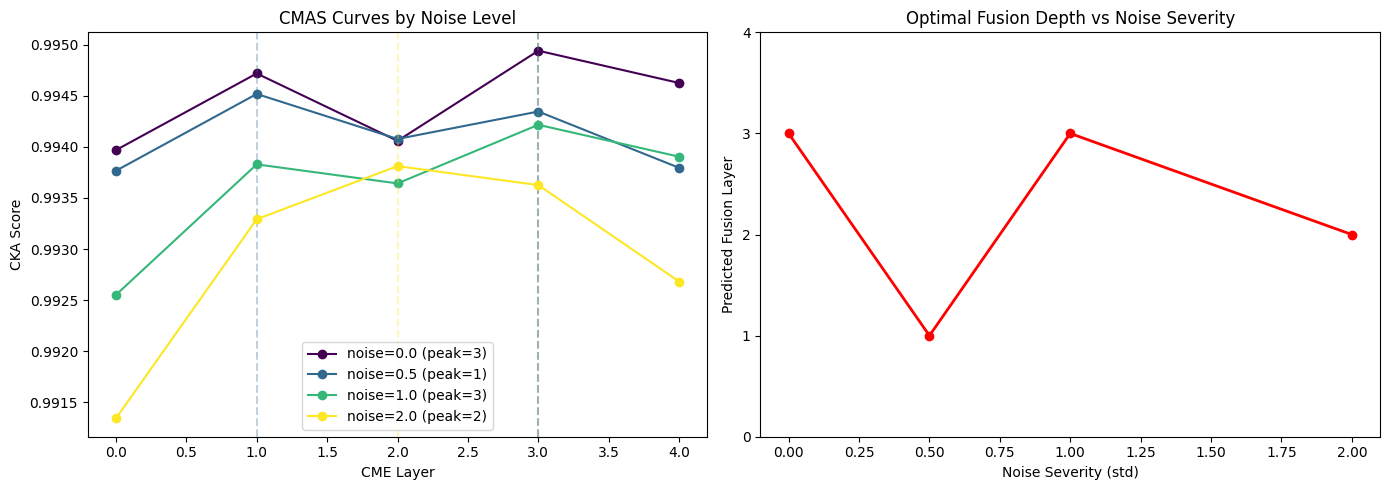

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

model = RAFT_MOSEI(cfg).to(device)
model.eval()  # untrained model — just for pipeline testing

noise_levels = [0.0, 0.5, 1.0, 2.0]
curves_by_noise = {}

with torch.no_grad():
    for noise_std in noise_levels:
        all_curves = []
        for i, batch in enumerate(val_loader):
            if i >= 20:
                break

            covarep = batch['covarep'].to(device)
            if noise_std > 0:
                covarep = covarep + torch.randn_like(covarep) * noise_std

            outputs = model(
                batch['text_tokens'].to(device),
                batch['text_masks'].to(device),
                covarep,
                batch['covarep_masks'].to(device),
                return_cka=True,
                fusion_layer=None
            )
            if 'cka_curve' in outputs:
                all_curves.append(outputs['cka_curve'])

        curves_by_noise[noise_std] = np.mean(all_curves, axis=0)
        print(f"noise={noise_std}: {[f'{s:.4f}' for s in curves_by_noise[noise_std]]}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: curves per noise level
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(noise_levels)))
for (noise_std, curve), color in zip(curves_by_noise.items(), colors):
    pred = int(np.argmax(curve))
    ax.plot(curve, marker='o', color=color, label=f'noise={noise_std} (peak={pred})')
    ax.axvline(x=pred, color=color, linestyle='--', alpha=0.3)
ax.set_xlabel("CME Layer")
ax.set_ylabel("CKA Score")
ax.set_title("CMAS Curves by Noise Level")
ax.legend()

# Plot 2: predicted fusion layer vs noise
ax = axes[1]
predicted = [int(np.argmax(curves_by_noise[n])) for n in noise_levels]
ax.plot(noise_levels, predicted, marker='o', color='red', linewidth=2)
ax.set_xlabel("Noise Severity (std)")
ax.set_ylabel("Predicted Fusion Layer")
ax.set_title("Optimal Fusion Depth vs Noise Severity")
ax.set_yticks(range(cfg.num_hidden_layers))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cmas_curves_quick.png', dpi=150)
plt.show()

In [ ]:

# RAFT Robustness Evaluation — Noisy Modality Testing

import sys
sys.path.insert(0, '/content/RAFT')

import os
import h5py
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from tqdm import tqdm
import pandas as pd
from copy import deepcopy

from utils.cross_attn_encoder import CMELayer, BertConfig
from utils.metricsTop import MetricsTop
from utils.noisy import NoisyTextGenerator, NoisyAudioGenerator  # actual RAFT noise

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:

class RobustnessConfig:
    hdf5_path = "/content/drive/MyDrive/mosei.hdf5"
    checkpoint_path = "/content/drive/MyDrive/mmai-raft-model/checkpoint/RAFT_acc_MOSEI_1.pth"  # from baseline training

    # Model config (must match training)
    train_mode = 'regression'
    dropout = 0.3
    cme_version = 'v1'
    num_hidden_layers = 5
    covarep_dim = 74
    audio_hidden_dim = 1024
    dataset_name = 'MOSEI'
    max_text_len = 96
    batch_size = 16
    seed = 1

    # Noise settings
    missing_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    noise_strategies = ['random', 'block']  # from RAFT's noisy.py
    noise_seeds = [42, 43, 44]

rcfg = RobustnessConfig()

In [ ]:


class NoisyCOVAREPGenerator:
    """
    Noise generator for COVAREP features, following the same
    interface as RAFT's NoisyAudioGenerator but for pre-extracted features.
    """
    def __init__(self, strategy='random', missing_rate=0.2):
        self.strategy = strategy
        self.missing_rate = missing_rate

    def random_drop(self, feat):
        """Zero out random frames."""
        T = feat.shape[0]
        mask = (np.random.rand(T) > self.missing_rate).astype(np.float32)
        return feat * mask[:, None]

    def block_drop(self, feat):
        """Zero out a contiguous block of frames."""
        T = feat.shape[0]
        block_len = max(1, int(T * self.missing_rate))
        if T <= block_len:
            return feat * 0.0
        start = np.random.randint(0, T - block_len)
        mask = np.ones(T, dtype=np.float32)
        mask[start:start + block_len] = 0.0
        return feat * mask[:, None]

    def gaussian_noise(self, feat):
        """Add Gaussian noise scaled by missing_rate."""
        std = self.missing_rate * np.std(feat)
        noise = np.random.randn(*feat.shape).astype(np.float32) * std
        return feat + noise

    def generate(self, feat):
        if self.strategy == 'random':
            return self.random_drop(feat)
        elif self.strategy == 'block':
            return self.block_drop(feat)
        elif self.strategy == 'gaussian':
            return self.gaussian_noise(feat)
        return feat


class NoisyMOSEIDataset(Dataset):
    """
    Same as MOSEIDatasetForRAFT but injects noise into specified modalities.

    noise_targets: list of modalities to corrupt, e.g. ['text'], ['audio'],
                   ['text', 'audio'], ['text', 'audio', 'visual']
    noise_strategy: 'random', 'block', or 'gaussian'
    missing_rate: fraction of data to corrupt (0.0 = clean, 1.0 = fully corrupted)
    """

    def __init__(self, hdf5_path, segment_ids, max_text_len=96,
                 noise_targets=None, noise_strategy='random', missing_rate=0.0,
                 noise_seeds=[42, 43, 44]):
        self.hdf5_path = hdf5_path
        self.segment_ids = segment_ids
        self.max_text_len = max_text_len
        self.tokenizer = AutoTokenizer.from_pretrained("roberta-large")

        self.noise_targets = noise_targets or []
        self.missing_rate = missing_rate

        # Initialize RAFT's actual noise generators
        if 'text' in self.noise_targets:
            self.text_noiser = NoisyTextGenerator(
                noise_seeds, strategy=noise_strategy, missing_rate=missing_rate
            )
        if 'audio' in self.noise_targets:
            self.audio_noiser = NoisyCOVAREPGenerator(
                strategy=noise_strategy, missing_rate=missing_rate
            )

    def __len__(self):
        return len(self.segment_ids)

    def _reconstruct_sentence(self, raw_words):
        words = []
        for i in range(raw_words.shape[0]):
            w = raw_words[i, 0]
            if isinstance(w, bytes):
                w = w.decode("utf-8", errors="ignore")
            w = w.strip()
            if len(w) > 0:
                words.append(w)
        return " ".join(words)

    def __getitem__(self, idx):
        seg_id = self.segment_ids[idx]

        with h5py.File(self.hdf5_path, "r") as f:
            raw_words = f["words"][seg_id]["features"][:]
            sentence = self._reconstruct_sentence(raw_words)
            covarep = f["COVAREP"][seg_id]["features"][:].astype(np.float32)
            label = f["All Labels"][seg_id]["features"][:].astype(np.float32)
            sentiment = float(label[0, 0])

        # Tokenize text
        tokenized = self.tokenizer(
            sentence,
            max_length=self.max_text_len,
            padding="max_length",
            truncation=True,
            add_special_tokens=True,
            return_attention_mask=True
        )

        input_ids = np.array(tokenized["input_ids"], dtype=np.float32)
        attention_mask = np.array(tokenized["attention_mask"], dtype=np.float32)

        # === INJECT TEXT NOISE (using RAFT's NoisyTextGenerator) ===
        if 'text' in self.noise_targets and self.missing_rate > 0:
            text_arr = np.stack([input_ids, attention_mask], axis=0)  # (2, seq_len)
            noisy_arr = self.text_noiser.generate(text_arr)
            input_ids = noisy_arr[0]

        # === INJECT AUDIO NOISE ===
        np.nan_to_num(covarep, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
        if 'audio' in self.noise_targets and self.missing_rate > 0:
            covarep = self.audio_noiser.generate(covarep)

        return {
            "text_tokens": torch.tensor(input_ids, dtype=torch.long),
            "text_masks": torch.tensor(attention_mask, dtype=torch.long),
            "covarep": torch.tensor(covarep, dtype=torch.float32),
            "targets": torch.tensor(sentiment, dtype=torch.float32),
        }


def collate_fn(batch):
    text_tokens = torch.stack([b["text_tokens"] for b in batch])
    text_masks = torch.stack([b["text_masks"] for b in batch])
    targets = torch.stack([b["targets"] for b in batch])

    covarep_list = [b["covarep"] for b in batch]
    max_len = max(c.shape[0] for c in covarep_list)
    covarep_dim = covarep_list[0].shape[1]

    covarep_padded = torch.zeros(len(batch), max_len, covarep_dim)
    covarep_masks = torch.zeros(len(batch), max_len)
    for i, c in enumerate(covarep_list):
        T = c.shape[0]
        covarep_padded[i, :T, :] = c
        covarep_masks[i, :T] = 1.0

    return {
        "text_tokens": text_tokens,
        "text_masks": text_masks,
        "covarep": covarep_padded,
        "covarep_masks": covarep_masks,
        "targets": targets,
    }



In [ ]:

def evaluate_noisy(model, hdf5_path, test_ids, noise_targets, noise_strategy,
                   missing_rate, batch_size=16, max_text_len=96):
    """Run evaluation with specified noise configuration."""
    metrics_fn = MetricsTop('regression').getMetics('MOSEI')

    ds = NoisyMOSEIDataset(
        hdf5_path, test_ids, max_text_len,
        noise_targets=noise_targets,
        noise_strategy=noise_strategy,
        missing_rate=missing_rate,
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_fn, num_workers=2, pin_memory=True)

    model.eval()
    y_pred, y_true = [], []

    with torch.no_grad():
        for batch in loader:
            text_tokens = batch["text_tokens"].to(device)
            text_masks = batch["text_masks"].to(device)
            covarep = batch["covarep"].to(device)
            covarep_masks = batch["covarep_masks"].to(device)
            targets = batch["targets"].to(device).view(-1, 1)

            outputs = model(text_tokens, text_masks, covarep, covarep_masks)
            y_pred.append(outputs['M'].cpu())
            y_true.append(targets.cpu())

    pred = torch.cat(y_pred)
    true = torch.cat(y_true)
    results = metrics_fn(pred, true)
    return results


In [ ]:


def get_split_ids(hdf5_path, seed=42):
    with h5py.File(hdf5_path, "r") as f:
        all_ids = sorted(f["All Labels"].keys())

    video_to_segs = {}
    for seg in all_ids:
        vid = seg.rsplit("[", 1)[0]
        video_to_segs.setdefault(vid, []).append(seg)

    video_ids = sorted(video_to_segs.keys())
    rng = np.random.RandomState(seed)
    rng.shuffle(video_ids)

    n = len(video_ids)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)
    test_vids = set(video_ids[n_train + n_val:])
    test_ids = [s for v in test_vids for s in video_to_segs[v]]
    return test_ids

test_ids = get_split_ids(rcfg.hdf5_path, rcfg.seed)
print(f"Test samples: {len(test_ids)}")


Test samples: 2466


In [ ]:

# Dummy config object matching training
class ModelConfig:
    dropout = rcfg.dropout
    cme_version = rcfg.cme_version
    num_hidden_layers = rcfg.num_hidden_layers
    covarep_dim = rcfg.covarep_dim
    audio_hidden_dim = rcfg.audio_hidden_dim

model = RAFT_MOSEI(ModelConfig()).to(device)
model.load_state_dict(torch.load(rcfg.checkpoint_path, map_location=device))
model.eval()
print("Model loaded from:", rcfg.checkpoint_path)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/mmai-raft-model/checkpoint/RAFT_acc_MOSEI_1.pth'

In [ ]:

noise_conditions = [
    {"label": "Text only",           "targets": ["text"]},
    {"label": "Audio only",          "targets": ["audio"]},
    {"label": "Text + Audio",        "targets": ["text", "audio"]},
]

all_results = []

for strategy in rcfg.noise_strategies:
    print(f"\n{'='*60}")
    print(f"NOISE STRATEGY: {strategy.upper()}")
    print(f"{'='*60}")

    for condition in noise_conditions:
        print(f"\n--- {condition['label']} ---")
        print(f"{'Rate':<8} {'Has0_acc2':<12} {'Non0_acc2':<12} {'MAE':<10} {'Corr':<10} {'Acc5':<10} {'Acc7':<10}")
        print("-" * 72)

        for rate in rcfg.missing_rates:
            results = evaluate_noisy(
                model, rcfg.hdf5_path, test_ids,
                noise_targets=condition["targets"],
                noise_strategy=strategy,
                missing_rate=rate,
                batch_size=rcfg.batch_size,
                max_text_len=rcfg.max_text_len
            )

            print(f"{rate:<8.1f} {results['Has0_acc_2']:<12.4f} {results['Non0_acc_2']:<12.4f} "
                  f"{results['MAE']:<10.4f} {results['Corr']:<10.4f} "
                  f"{results['Mult_acc_5']:<10.4f} {results['Mult_acc_7']:<10.4f}")

            all_results.append({
                "strategy": strategy,
                "condition": condition["label"],
                "missing_rate": rate,
                **results
            })


NOISE STRATEGY: RANDOM

--- Text only ---
Rate     Has0_acc2    Non0_acc2    MAE        Corr       Acc5       Acc7      
------------------------------------------------------------------------
0.0      0.8646       0.8614       0.5696     0.7763     0.5345     0.5097    
0.1      0.8581       0.8487       0.5941     0.7424     0.5288     0.5065    
0.2      0.8418       0.8273       0.6008     0.7258     0.5195     0.4972    
0.3      0.8313       0.8136       0.6273     0.6705     0.5191     0.5004    
0.4      0.8151       0.7871       0.6650     0.6156     0.4911     0.4749    
0.5      0.7924       0.7590       0.7098     0.5280     0.4708     0.4582    
0.6      0.7575       0.7112       0.7534     0.4269     0.4574     0.4513    
0.7      0.7551       0.6999       0.7740     0.3521     0.4489     0.4428    
0.8      0.7344       0.6694       0.8110     0.2260     0.4290     0.4262    
0.9      0.7315       0.6628       0.8217     0.1607     0.4189     0.4185    

--- Audio only

In [ ]:

df = pd.DataFrame(all_results)
csv_path = "/content/raft_robustness_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nResults saved to: {csv_path}")

# Print summary: performance drop from clean (rate=0.0) to each noise level
print("\n" + "=" * 60)
print("PERFORMANCE DROP SUMMARY (Has0_acc_2)")
print("=" * 60)

for strategy in rcfg.noise_strategies:
    print(f"\nStrategy: {strategy}")
    sub = df[df['strategy'] == strategy]
    for condition in noise_conditions:
        cond_df = sub[sub['condition'] == condition['label']].sort_values('missing_rate')
        clean_acc = cond_df[cond_df['missing_rate'] == 0.0]['Has0_acc_2'].values[0]
        print(f"\n  {condition['label']} (clean baseline: {clean_acc:.4f})")
        for _, row in cond_df.iterrows():
            if row['missing_rate'] == 0.0:
                continue
            drop = clean_acc - row['Has0_acc_2']
            pct = (drop / clean_acc) * 100 if clean_acc > 0 else 0
            print(f"    rate={row['missing_rate']:.1f}  acc={row['Has0_acc_2']:.4f}  "
                  f"drop={drop:+.4f} ({pct:+.1f}%)")



Results saved to: /content/raft_robustness_results.csv

PERFORMANCE DROP SUMMARY (Has0_acc_2)

Strategy: random

  Text only (clean baseline: 0.8646)
    rate=0.1  acc=0.8581  drop=+0.0065 (+0.8%)
    rate=0.2  acc=0.8418  drop=+0.0228 (+2.6%)
    rate=0.3  acc=0.8313  drop=+0.0333 (+3.9%)
    rate=0.4  acc=0.8151  drop=+0.0495 (+5.7%)
    rate=0.5  acc=0.7924  drop=+0.0722 (+8.4%)
    rate=0.6  acc=0.7575  drop=+0.1071 (+12.4%)
    rate=0.7  acc=0.7551  drop=+0.1095 (+12.7%)
    rate=0.8  acc=0.7344  drop=+0.1302 (+15.1%)
    rate=0.9  acc=0.7315  drop=+0.1331 (+15.4%)

  Audio only (clean baseline: 0.8646)
    rate=0.1  acc=0.8625  drop=+0.0021 (+0.2%)
    rate=0.2  acc=0.8629  drop=+0.0017 (+0.2%)
    rate=0.3  acc=0.8637  drop=+0.0009 (+0.1%)
    rate=0.4  acc=0.8633  drop=+0.0013 (+0.2%)
    rate=0.5  acc=0.8633  drop=+0.0013 (+0.2%)
    rate=0.6  acc=0.8609  drop=+0.0037 (+0.4%)
    rate=0.7  acc=0.8617  drop=+0.0029 (+0.3%)
    rate=0.8  acc=0.8609  drop=+0.0037 (+0.4%)
    rat

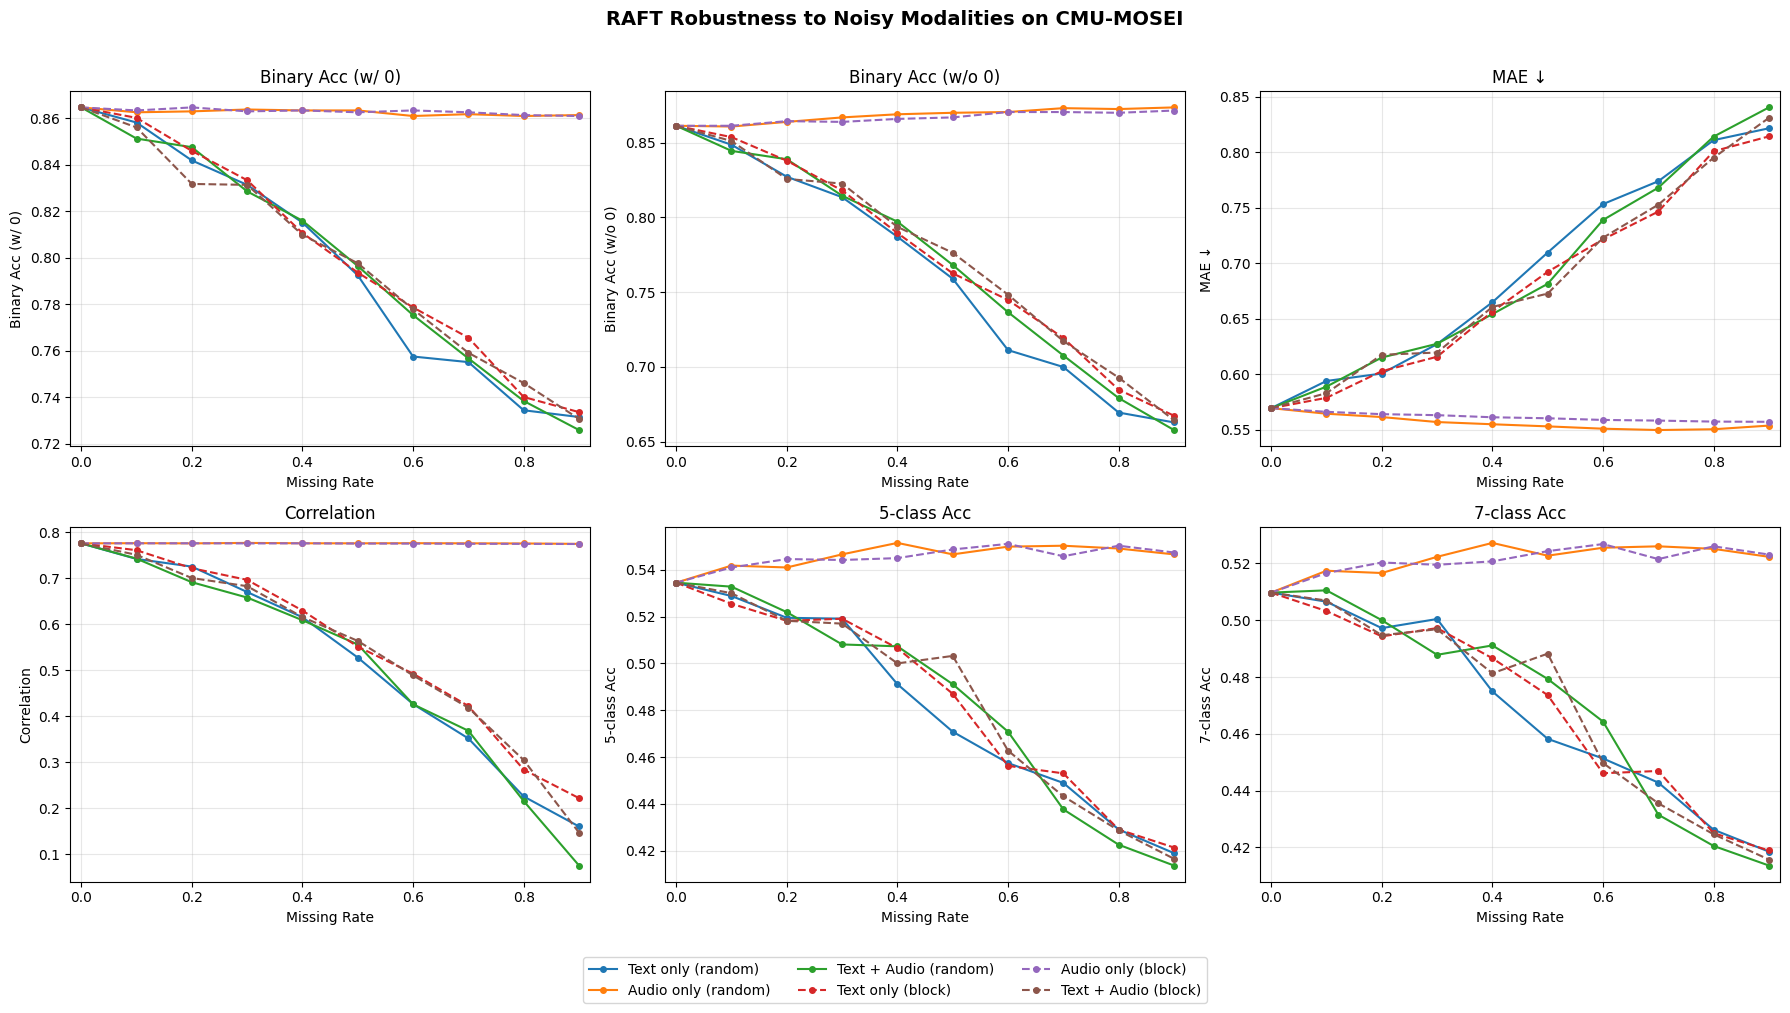

Plot saved to /content/raft_robustness_plot.png


In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['Has0_acc_2', 'Non0_acc_2', 'MAE', 'Corr', 'Mult_acc_5', 'Mult_acc_7']
metric_labels = ['Binary Acc (w/ 0)', 'Binary Acc (w/o 0)', 'MAE ↓', 'Correlation', '5-class Acc', '7-class Acc']

for ax, metric, label in zip(axes.flatten(), metrics_to_plot, metric_labels):
    for strategy in rcfg.noise_strategies:
        for condition in noise_conditions:
            sub = df[(df['strategy'] == strategy) & (df['condition'] == condition['label'])]
            sub = sub.sort_values('missing_rate')
            linestyle = '-' if strategy == 'random' else '--'
            ax.plot(sub['missing_rate'], sub[metric],
                    marker='o', markersize=4, linestyle=linestyle,
                    label=f"{condition['label']} ({strategy})")

    ax.set_xlabel('Missing Rate')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 0.92)

# Single legend at bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('RAFT Robustness to Noisy Modalities on CMU-MOSEI', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig('/content/raft_robustness_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to /content/raft_robustness_plot.png")

In [ ]:

print("\n" + "=" * 60)
print("GAUSSIAN NOISE SWEEP (additive, not dropout)")
print("=" * 60)

gaussian_results = []
gaussian_rates = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

for condition in noise_conditions:
    print(f"\n--- {condition['label']} ---")
    print(f"{'Rate':<8} {'Has0_acc2':<12} {'Non0_acc2':<12} {'MAE':<10} {'Corr':<10}")
    print("-" * 52)

    for rate in gaussian_rates:
        results = evaluate_noisy(
            model, rcfg.hdf5_path, test_ids,
            noise_targets=condition["targets"],
            noise_strategy='gaussian',
            missing_rate=rate,
            batch_size=rcfg.batch_size,
            max_text_len=rcfg.max_text_len
        )
        print(f"{rate:<8.1f} {results['Has0_acc_2']:<12.4f} {results['Non0_acc_2']:<12.4f} "
              f"{results['MAE']:<10.4f} {results['Corr']:<10.4f}")

        gaussian_results.append({
            "strategy": "gaussian",
            "condition": condition["label"],
            "missing_rate": rate,
            **results
        })

df_gauss = pd.DataFrame(gaussian_results)
df_gauss.to_csv("/content/raft_robustness_gaussian.csv", index=False)
print("\nGaussian results saved to /content/raft_robustness_gaussian.csv")


GAUSSIAN NOISE SWEEP (additive, not dropout)

--- Text only ---
Rate     Has0_acc2    Non0_acc2    MAE        Corr      
----------------------------------------------------
0.0      0.8646       0.8614       0.5696     0.7763    
0.1      0.8646       0.8614       0.5696     0.7763    
0.2      0.8646       0.8614       0.5696     0.7763    
0.3      0.8646       0.8614       0.5696     0.7763    
0.5      0.8646       0.8614       0.5696     0.7763    
0.7      0.8646       0.8614       0.5696     0.7763    
1.0      0.8646       0.8614       0.5696     0.7763    

--- Audio only ---
Rate     Has0_acc2    Non0_acc2    MAE        Corr      
----------------------------------------------------
0.0      0.8646       0.8614       0.5696     0.7763    
0.1      0.8646       0.8619       0.5688     0.7762    
0.2      0.8633       0.8630       0.5668     0.7763    
0.3      0.8650       0.8645       0.5653     0.7761    
0.5      0.8633       0.8655       0.5629     0.7761    
0.7      0.